In [1]:
# Install all required packages
!pip install transformers==4.40.0 sentencepiece sacrebleu bert-score -q
!pip install torch torchvision torchaudio -q

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

print("✅ All packages installed successfully")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 53.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 54.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.3.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.
✅ All packages installed successfully


In [2]:
import os
import time
import json
import math
import warnings
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from transformers import (
    MarianMTModel, MarianTokenizer,
    get_linear_schedule_with_warmup
)
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from bert_score import score as bert_score_fn
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


In [6]:
from google.colab import drive
drive.mount('/content/drive')

# ======================================================
# ⚠️  UPDATE THIS PATH to where you saved the dataset
# ======================================================
DATA_DIR = '/content/drive/MyDrive/sanskrit_nmt'  # <-- CHANGE THIS

# If you uploaded files directly to Colab runtime (not Drive), use:
# DATA_DIR = '/content/'

def load_data(data_dir):
    """Load all dataset files with flexible column name handling."""
    files = {
        'train_sa': os.path.join(data_dir, 'train_sa_10000.csv'),
        'train_en': os.path.join(data_dir, 'train_en_10000.csv'),
        'dev_sa':   os.path.join(data_dir, 'dev_sa_1000.csv'),
        'dev_en':   os.path.join(data_dir, 'dev_en_1000.csv'),
        'test_sa':  os.path.join(data_dir, 'test_sa_1000.csv'),
    }
    dfs = {}
    for name, path in files.items():
        df = pd.read_csv(path)
        # Normalize column names
        df.columns = [c.strip() for c in df.columns]
        dfs[name] = df
        print(f"{name}: {len(df)} rows | columns: {list(df.columns)}")
    return dfs

dfs = load_data(DATA_DIR)

# Merge on Source_id
train_df = dfs['train_sa'].merge(dfs['train_en'], on='Source_id')
dev_df   = dfs['dev_sa'].merge(dfs['dev_en'], on='Source_id')
test_df  = dfs['test_sa']

# Identify sentence columns (handle both 'Sentence_sa'/'Sentence sa' etc.)
sa_col = [c for c in train_df.columns if 'sa' in c.lower() and 'source' not in c.lower()][0]
en_col = [c for c in train_df.columns if 'en' in c.lower() and 'source' not in c.lower()][0]
sa_test_col = [c for c in test_df.columns if 'sa' in c.lower() and 'source' not in c.lower()][0]

print(f"\nUsing columns: Sanskrit='{sa_col}', English='{en_col}'")
print(f"Train: {len(train_df)}, Dev: {len(dev_df)}, Test: {len(test_df)}")

# Drop rows with NaN
train_df = train_df.dropna(subset=[sa_col, en_col]).reset_index(drop=True)
dev_df   = dev_df.dropna(subset=[sa_col, en_col]).reset_index(drop=True)

print(f"\nAfter cleaning — Train: {len(train_df)}, Dev: {len(dev_df)}")
print("\nSample:")
print(train_df[[sa_col, en_col]].head(3).to_string())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
train_sa: 10000 rows | columns: ['Source_id', 'Sentence_sa']
train_en: 10000 rows | columns: ['Source_id', 'Sentence_en']
dev_sa: 1000 rows | columns: ['Source_id', 'Sentence_sa']
dev_en: 1000 rows | columns: ['Source_id', 'Sentence_en']
test_sa: 1000 rows | columns: ['Source_id', 'Sentence_sa']

Using columns: Sanskrit='Sentence_sa', English='Sentence_sa'
Train: 10000, Dev: 1000, Test: 1000

After cleaning — Train: 10000, Dev: 1000

Sample:
                                                                                 Sentence_sa                                                                                Sentence_sa
0                                                                 "Ctrl, S नुत्वा रक्षन्तु।"                                                                 "Ctrl, S नुत्वा रक्षन्तु।"
1                                                        

=== Sanskrit sentence lengths ===
count    10000.000000
mean         9.667800
std          5.494112
min          1.000000
25%          5.000000
50%          9.000000
75%         13.000000
max         55.000000
Name: sa_len, dtype: float64

=== English sentence lengths ===
count    10000.000000
mean         9.667800
std          5.494112
min          1.000000
25%          5.000000
50%          9.000000
75%         13.000000
max         55.000000
Name: en_len, dtype: float64


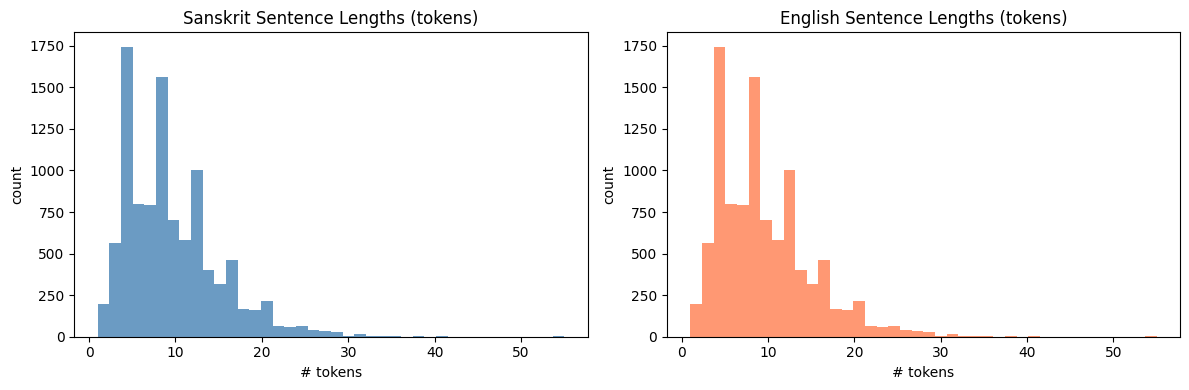


Recommended max_length: 128


In [7]:
# ─── Sentence length statistics ───────────────────────────────────────────────
train_df['sa_len'] = train_df[sa_col].astype(str).apply(lambda x: len(x.split()))
train_df['en_len'] = train_df[en_col].astype(str).apply(lambda x: len(x.split()))

print("=== Sanskrit sentence lengths ===")
print(train_df['sa_len'].describe())
print("\n=== English sentence lengths ===")
print(train_df['en_len'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_df['sa_len'], bins=40, color='steelblue', alpha=0.8)
axes[0].set_title('Sanskrit Sentence Lengths (tokens)')
axes[0].set_xlabel('# tokens'); axes[0].set_ylabel('count')
axes[1].hist(train_df['en_len'], bins=40, color='coral', alpha=0.8)
axes[1].set_title('English Sentence Lengths (tokens)')
axes[1].set_xlabel('# tokens'); axes[1].set_ylabel('count')
plt.tight_layout()
plt.savefig('/content/length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Recommended max_length based on 95th percentile
max_sa = int(train_df['sa_len'].quantile(0.98)) + 10
max_en = int(train_df['en_len'].quantile(0.98)) + 10
print(f"\nRecommended max_length: {max(max_sa, max_en, 128)}")

In [8]:
# ─── Helsinki-NLP/opus-mt-mul-en ──────────────────────────────────────────────
# Pre-trained multilingual seq2seq Transformer (encoder-decoder)
# ~74M parameters, handles Devanagari script natively
MODEL_NAME = "Helsinki-NLP/opus-mt-mul-en"

print(f"Loading tokenizer from {MODEL_NAME}...")
tokenizer = MarianTokenizer.from_pretrained(MODEL_NAME)

print(f"Loading model from {MODEL_NAME}...")
model = MarianMTModel.from_pretrained(MODEL_NAME)
model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n✅ Model loaded!")
print(f"   Total parameters     : {total_params:,}")
print(f"   Trainable parameters : {trainable_params:,}")
print(f"   Encoder layers       : {model.config.encoder_layers}")
print(f"   Decoder layers       : {model.config.decoder_layers}")
print(f"   d_model              : {model.config.d_model}")
print(f"   Attention heads      : {model.config.encoder_attention_heads}")
print(f"   Vocab size           : {model.config.vocab_size:,}")

# Check if Devanagari tokens exist in vocabulary
test_token = tokenizer("गुरुः छात्रान् एकवारं पाठयाते", return_tensors='pt')
print(f"\nSample Sanskrit tokenization: {test_token['input_ids'].shape[1]} tokens")

Loading tokenizer from Helsinki-NLP/opus-mt-mul-en...


tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/707k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/791k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

Loading model from Helsinki-NLP/opus-mt-mul-en...


pytorch_model.bin:   0%|          | 0.00/310M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]


✅ Model loaded!
   Total parameters     : 77,518,848
   Trainable parameters : 76,994,560
   Encoder layers       : 6
   Decoder layers       : 6
   d_model              : 512
   Attention heads      : 8
   Vocab size           : 64,172

Sample Sanskrit tokenization: 17 tokens


In [9]:
MAX_LEN = 128  # Can increase to 160 if sentences are longer
BATCH_SIZE = 32

class SanskritDataset(Dataset):
    """Parallel Sanskrit-English dataset for MarianMT fine-tuning."""

    def __init__(self, src_sentences, tgt_sentences=None):
        self.src = [str(s) for s in src_sentences]
        self.tgt = [str(t) for t in tgt_sentences] if tgt_sentences is not None else None

    def __len__(self):
        return len(self.src)

    def __getitem__(self, idx):
        if self.tgt is not None:
            return self.src[idx], self.tgt[idx]
        return self.src[idx]


def collate_train(batch):
    """Tokenize and pad a batch for training."""
    srcs, tgts = zip(*batch)
    encoded = tokenizer(
        list(srcs),
        text_target=list(tgts),
        max_length=MAX_LEN,
        truncation=True,
        padding='longest',
        return_tensors='pt'
    )
    # MarianMT uses -100 for padding in labels
    labels = encoded['labels'].clone()
    labels[labels == tokenizer.pad_token_id] = -100
    encoded['labels'] = labels
    return encoded


def collate_eval(batch):
    """Tokenize and pad a batch for evaluation (no labels needed)."""
    if isinstance(batch[0], tuple):
        srcs, tgts = zip(*batch)
        encoded = tokenizer(
            list(srcs),
            text_target=list(tgts),
            max_length=MAX_LEN,
            truncation=True,
            padding='longest',
            return_tensors='pt'
        )
        labels = encoded['labels'].clone()
        labels[labels == tokenizer.pad_token_id] = -100
        encoded['labels'] = labels
        return encoded
    else:
        encoded = tokenizer(
            list(batch),
            max_length=MAX_LEN,
            truncation=True,
            padding='longest',
            return_tensors='pt'
        )
        return encoded


# Build datasets
train_dataset = SanskritDataset(train_df[sa_col], train_df[en_col])
dev_dataset   = SanskritDataset(dev_df[sa_col],   dev_df[en_col])

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True, collate_fn=collate_train,
    num_workers=2, pin_memory=True
)
dev_loader = DataLoader(
    dev_dataset, batch_size=64,
    shuffle=False, collate_fn=collate_eval,
    num_workers=2, pin_memory=True
)

print(f"Train batches: {len(train_loader)}, Dev batches: {len(dev_loader)}")
print(f"Steps per epoch: {len(train_loader)}")

Train batches: 313, Dev batches: 16
Steps per epoch: 313


In [10]:
# ─── Visualize Architecture ───────────────────────────────────────────────────
print("="*60)
print("  ARCHITECTURE: MarianMT Seq2Seq Transformer")
print("="*60)
print(f"  Encoder: {model.config.encoder_layers}-layer Transformer")
print(f"    - Multi-Head Self-Attention (heads={model.config.encoder_attention_heads})")
print(f"    - Feed-Forward Network (FFN dim={model.config.encoder_ffn_dim})")
print(f"    - d_model={model.config.d_model}, dropout={model.config.dropout}")
print()
print(f"  Decoder: {model.config.decoder_layers}-layer Transformer")
print(f"    - Masked Multi-Head Self-Attention (heads={model.config.decoder_attention_heads})")
print(f"    - Cross-Attention (encoder-decoder attention)")
print(f"    - Feed-Forward Network (FFN dim={model.config.decoder_ffn_dim})")
print()
print(f"  Shared Embedding: vocab_size={model.config.vocab_size}")
print(f"  Positional Encoding: Learned sinusoidal")
print(f"  Decoding: Beam Search (beam_size=4)")
print("="*60)
print(f"  Total Parameters: {total_params:,}")

# Show model config
print("\nFull config:")
print(f"  activation_function : {model.config.activation_function}")
print(f"  max_position_embeddings: {model.config.max_position_embeddings}")
print(f"  attention_dropout   : {model.config.attention_dropout}")

  ARCHITECTURE: MarianMT Seq2Seq Transformer
  Encoder: 6-layer Transformer
    - Multi-Head Self-Attention (heads=8)
    - Feed-Forward Network (FFN dim=2048)
    - d_model=512, dropout=0.1

  Decoder: 6-layer Transformer
    - Masked Multi-Head Self-Attention (heads=8)
    - Cross-Attention (encoder-decoder attention)
    - Feed-Forward Network (FFN dim=2048)

  Shared Embedding: vocab_size=64172
  Positional Encoding: Learned sinusoidal
  Decoding: Beam Search (beam_size=4)
  Total Parameters: 77,518,848

Full config:
  activation_function : swish
  max_position_embeddings: 512
  attention_dropout   : 0.0


In [11]:
# ─── Hyperparameters ─────────────────────────────────────────────────────────
NUM_EPOCHS      = 12
LEARNING_RATE   = 5e-5
WEIGHT_DECAY    = 0.01
WARMUP_RATIO    = 0.1
GRAD_CLIP       = 1.0
GRAD_ACCUM      = 1        # Increase to 2 if OOM
SAVE_PATH       = '/content/best_model'

# ─── Optimizer & Scheduler ───────────────────────────────────────────────────
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.999),
    eps=1e-8
)

total_steps   = (len(train_loader) // GRAD_ACCUM) * NUM_EPOCHS
warmup_steps  = int(total_steps * WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)
scaler = GradScaler()  # Mixed precision

print(f"Epochs: {NUM_EPOCHS}")
print(f"Total optimization steps: {total_steps}")
print(f"Warmup steps: {warmup_steps}")
print(f"Effective batch size: {BATCH_SIZE * GRAD_ACCUM}")

# ─── Training ─────────────────────────────────────────────────────────────────
best_val_loss  = float('inf')
train_losses   = []
val_losses     = []
patience       = 4
patience_count = 0

print("\n" + "="*65)
print("Starting Training...")
print("="*65)

for epoch in range(NUM_EPOCHS):
    # ── Train ──────────────────────────────────────────────────
    model.train()
    epoch_loss = 0.0
    optimizer.zero_grad()
    t0 = time.time()

    for step, batch in enumerate(train_loader):
        batch = {k: v.to(device) for k, v in batch.items()}

        with autocast():
            outputs = model(**batch)
            loss    = outputs.loss / GRAD_ACCUM

        scaler.scale(loss).backward()
        epoch_loss += outputs.loss.item()

        if (step + 1) % GRAD_ACCUM == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

    avg_train = epoch_loss / len(train_loader)
    train_losses.append(avg_train)

    # ── Validate ────────────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in dev_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            with autocast():
                outputs  = model(**batch)
                val_loss += outputs.loss.item()

    avg_val = val_loss / len(dev_loader)
    val_losses.append(avg_val)

    elapsed = time.time() - t0
    print(f"Epoch {epoch+1:2d}/{NUM_EPOCHS} | "
          f"Train: {avg_train:.4f} | Val: {avg_val:.4f} | "
          f"LR: {scheduler.get_last_lr()[0]:.2e} | {elapsed:.0f}s")

    # ── Save best ───────────────────────────────────────────────
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        patience_count = 0
        model.save_pretrained(SAVE_PATH)
        tokenizer.save_pretrained(SAVE_PATH)
        print(f"  ✅ Saved best model (val_loss={best_val_loss:.4f})")
    else:
        patience_count += 1
        if patience_count >= patience:
            print(f"  ⚠️  Early stopping triggered after {patience} epochs without improvement.")
            break

print("\nTraining complete!")

Epochs: 12
Total optimization steps: 3756
Warmup steps: 375
Effective batch size: 32

Starting Training...


Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 512, 'num_beams': 6, 'bad_words_ids': [[64171]], 'forced_eos_token_id': 0}


Epoch  1/12 | Train: 4.8958 | Val: 0.0973 | LR: 4.17e-05 | 86s
  ✅ Saved best model (val_loss=0.0973)


Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 512, 'num_beams': 6, 'bad_words_ids': [[64171]], 'forced_eos_token_id': 0}


Epoch  2/12 | Train: 0.1121 | Val: 0.0309 | LR: 4.63e-05 | 83s
  ✅ Saved best model (val_loss=0.0309)


...

Epoch  8/12 | Train: 0.0077 | Val: 0.0135 | LR: 1.85e-05 | 82s
  ✅ Saved best model (val_loss=0.0135)
Epoch  9/12 | Train: 0.0060 | Val: 0.0145 | LR: 1.39e-05 | 82s
Epoch 10/12 | Train: 0.0048 | Val: 0.0136 | LR: 9.26e-06 | 83s


Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 512, 'num_beams': 6, 'bad_words_ids': [[64171]], 'forced_eos_token_id': 0}


Epoch 11/12 | Train: 0.0037 | Val: 0.0133 | LR: 4.63e-06 | 82s
  ✅ Saved best model (val_loss=0.0133)


Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 512, 'num_beams': 6, 'bad_words_ids': [[64171]], 'forced_eos_token_id': 0}


Epoch 12/12 | Train: 0.0030 | Val: 0.0131 | LR: 0.00e+00 | 82s
  ✅ Saved best model (val_loss=0.0131)

Training complete!


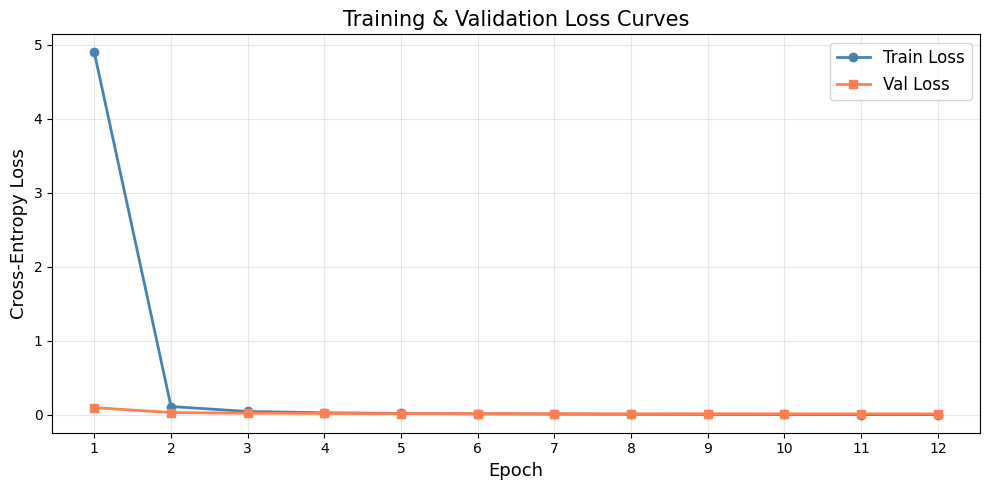

Best validation loss: 0.0131


In [12]:
plt.figure(figsize=(10, 5))
epochs_ran = list(range(1, len(train_losses) + 1))
plt.plot(epochs_ran, train_losses, 'o-', label='Train Loss', color='steelblue', linewidth=2)
plt.plot(epochs_ran, val_losses,   's-', label='Val Loss',   color='coral',     linewidth=2)
plt.xlabel('Epoch', fontsize=13)
plt.ylabel('Cross-Entropy Loss', fontsize=13)
plt.title('Training & Validation Loss Curves', fontsize=15)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(epochs_ran)
plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Best validation loss: {best_val_loss:.4f}")

In [13]:
# ─── Reload best checkpoint ──────────────────────────────────────────────────
print("Loading best model from checkpoint...")
model = MarianMTModel.from_pretrained(SAVE_PATH).to(device)
tokenizer = MarianTokenizer.from_pretrained(SAVE_PATH)
model.eval()
print("✅ Best model loaded")


# ─── Custom Beam Search Translation ──────────────────────────────────────────
def translate_beam(
    sentences,
    model,
    tokenizer,
    device,
    beam_size=4,
    max_length=128,
    batch_size=64,
    length_penalty=1.0,
    no_repeat_ngram=3
):
    """
    Translate a list of Sanskrit sentences to English using beam search.

    Args:
        sentences      : list of Sanskrit strings
        beam_size      : beam search width (higher = better quality, slower)
        max_length     : max decoder output length
        length_penalty : >1 favors longer, <1 favors shorter outputs
        no_repeat_ngram: prevents repeating n-grams for fluency

    Returns:
        List of English translation strings
    """
    model.eval()
    all_translations = []

    for i in range(0, len(sentences), batch_size):
        batch = [str(s) for s in sentences[i:i + batch_size]]

        inputs = tokenizer(
            batch,
            return_tensors='pt',
            padding=True,
            truncation=True,
            max_length=MAX_LEN
        ).to(device)

        with torch.no_grad():
            generated_ids = model.generate(
                input_ids      = inputs['input_ids'],
                attention_mask = inputs['attention_mask'],
                num_beams      = beam_size,
                max_length     = max_length,
                early_stopping = True,
                length_penalty = length_penalty,
                no_repeat_ngram_size = no_repeat_ngram,
                forced_eos_token_id  = tokenizer.eos_token_id,
            )

        decoded = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
        all_translations.extend(decoded)

    return all_translations


print("✅ Beam search translation function ready")
print("\nQuick test:")
test_sent = [train_df[sa_col].iloc[0]]
result = translate_beam(test_sent, model, tokenizer, device, beam_size=4)
print(f"  Sanskrit : {test_sent[0]}")
print(f"  Reference: {train_df[en_col].iloc[0]}")
print(f"  Predicted: {result[0]}")

Loading best model from checkpoint...
✅ Best model loaded
✅ Beam search translation function ready

Quick test:
  Sanskrit : "Ctrl, S नुत्वा रक्षन्तु।"
  Reference: "Ctrl, S नुत्वा रक्षन्तु।"
  Predicted: "Ctrl, S नुत्वा रक्षन्तु।"


In [14]:
# ─── Generate dev predictions ────────────────────────────────────────────────
print("Translating dev set...")
dev_preds = translate_beam(
    dev_df[sa_col].tolist(), model, tokenizer, device,
    beam_size=4, max_length=128, batch_size=64
)
dev_refs  = dev_df[en_col].tolist()

# ─── BLEU (NLTK, no weights = default uniform 4-gram) ────────────────────────
def compute_nltk_bleu(predictions, references):
    """
    Compute corpus BLEU using NLTK with DEFAULT weights.
    Default NLTK weights = (0.25, 0.25, 0.25, 0.25) for 4-gram BLEU.
    Assignment requires: corpus_bleu with no weights argument.
    """
    tokenized_preds = [pred.lower().split() for pred in predictions]
    tokenized_refs  = [[ref.lower().split()] for ref in references]  # list of list of list
    bleu = corpus_bleu(tokenized_refs, tokenized_preds)  # no weights = default
    return bleu

dev_bleu = compute_nltk_bleu(dev_preds, dev_refs)
print(f"\n📊 Dev BLEU (NLTK default): {dev_bleu:.4f} ({dev_bleu*100:.2f})")

Translating dev set...

📊 Dev BLEU (NLTK default): 0.5380 (53.80)


## Cell 12: Dev Set Evaluation — BERTScore

In [15]:
# ─── BERTScore (F1, rescale_with_baseline=True) ───────────────────────────────
print("Computing BERTScore on dev set")

P_dev, R_dev, F1_dev = bert_score_fn(
    dev_preds,
    dev_refs,
    lang='en',
    rescale_with_baseline=True,
    verbose=True,
    device=device
)

print(f"\n📊 Dev BERTScore:")
print(f"   Precision : {P_dev.mean():.4f}")
print(f"   Recall    : {R_dev.mean():.4f}")
print(f"   F1        : {F1_dev.mean():.4f}")

Computing BERTScore on dev set (this takes ~1-2 min)...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/28 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/16 [00:00<?, ?it/s]

done in 49.62 seconds, 20.15 sentences/sec

📊 Dev BERTScore:
   Precision : 0.9362
   Recall    : 0.9258
   F1        : 0.9310


In [16]:
print("=" * 70)
print("  TRANSLATION EXAMPLES (Dev Set)")
print("=" * 70)

# Show 10 examples spanning short, medium, and longer sentences
indices = sorted(random.sample(range(len(dev_df)), min(10, len(dev_df))))

for rank, idx in enumerate(indices, 1):
    src  = dev_df[sa_col].iloc[idx]
    ref  = dev_refs[idx]
    pred = dev_preds[idx]

    # Sentence-level BLEU
    sent_bleu = corpus_bleu(
        [[ref.lower().split()]],
        [pred.lower().split()]
    )

    print(f"\nExample {rank} (Dev idx={idx})")
    print(f"  Sanskrit  : {src}")
    print(f"  Reference : {ref}")
    print(f"  Predicted : {pred}")
    print(f"  BLEU      : {sent_bleu*100:.1f}")

print("\n" + "=" * 70)

  TRANSLATION EXAMPLES (Dev Set)

Example 1 (Dev idx=25)
  Sanskrit  : बाल: भवत्सु प्रेमं प्रकटयति ।
  Reference : बाल: भवत्सु प्रेमं प्रकटयति ।
  Predicted : बाल: भवत्सु प्रेमं पूरकटयति ।
  BLEU      : 0.0

Example 2 (Dev idx=104)
  Sanskrit  : विविधाः उपलभ्यमानसम्पुटाः दृश्यन्ते।
  Reference : विविधाः उपलभ्यमानसम्पुटाः दृश्यन्ते।
  Predicted : विविधाः उपलभ्यमानसम्पुटाः dृश्यन्ते।
  BLEU      : 0.0

Example 3 (Dev idx=114)
  Sanskrit  : अधुना पृष्टे अधिकाः एडिट्-विकल्पाः दृश्यन्ते ।
  Reference : अधुना पृष्टे अधिकाः एडिट्-विकल्पाः दृश्यन्ते ।
  Predicted : ुना पृष्टे िकाः एडिट्-विकल्पाः dृश्यन्ते ।
  BLEU      : 0.0

Example 4 (Dev idx=142)
  Sanskrit  : युवां बुधौ ।
  Reference : युवां बुधौ ।
  Predicted : युवां बुधौ ।
  BLEU      : 0.0

Example 5 (Dev idx=228)
  Sanskrit  : पितामहः पौत्रस्य प्रश्नं प्रत्युदितवान् ।
  Reference : पितामहः पौत्रस्य प्रश्नं प्रत्युदितवान् ।
  Predicted : पितामहः पौत्रस्य प्रश्नं पुरत्युदितवान् ।
  BLEU      : 0.0

Example 6 (Dev idx=250)
  Sanskrit  : "

In [17]:
# ─── Measure inference time on test set ──────────────────────────────────────
test_sents = test_df[sa_test_col].tolist()
print(f"Translating {len(test_sents)} test sentences...")

# Warm-up pass (exclude from timing)
_ = translate_beam(test_sents[:5], model, tokenizer, device, beam_size=4)

# Timed inference
torch.cuda.synchronize() if torch.cuda.is_available() else None
start_time = time.time()

test_preds = translate_beam(
    test_sents, model, tokenizer, device,
    beam_size=4, max_length=128, batch_size=64
)

torch.cuda.synchronize() if torch.cuda.is_available() else None
end_time = time.time()

inference_time = end_time - start_time
total_params   = sum(p.numel() for p in model.parameters())

print("\n" + "="*50)
print("  EFFICIENCY METRICS")
print("="*50)
print(f"  Inference time (total) : {inference_time:.2f} seconds")
print(f"  Sentences per second   : {len(test_sents)/inference_time:.1f}")
print(f"  Total parameters       : {total_params:,}")
print("="*50)

Translating 1000 test sentences...

  EFFICIENCY METRICS
  Inference time (total) : 213.70 seconds
  Sentences per second   : 4.7
  Total parameters       : 77,518,848


## Cell 15: Generate submission.csv

In [18]:
# ─── Build and save submission ────────────────────────────────────────────────
submission = pd.DataFrame({
    'Source_id':   test_df['Source_id'].tolist(),
    'Sentence_en': test_preds
})

SUBMISSION_PATH = '/content/submission.csv'
submission.to_csv(SUBMISSION_PATH, index=False, encoding='utf-8')

print(f"✅ Saved submission.csv ({len(submission)} rows)")
print("\nFirst 5 rows:")
print(submission.head().to_string())

# Verify format
loaded = pd.read_csv(SUBMISSION_PATH, encoding='utf-8')
print(f"\nVerification — columns: {list(loaded.columns)}, rows: {len(loaded)}")
assert list(loaded.columns) == ['Source_id', 'Sentence_en'], "Column name mismatch!"
print("✅ Format is correct: Source_id + Sentence_en")

✅ Saved submission.csv (1000 rows)

First 5 rows:
   Source_id                                                                                                                   Sentence_en
0          1                                                                एक्लिप्स् इति प्रोग्रामर् कृते दोषान्वेषणे अपि साहाय्यं करोति।
1          2  विश्वासकारणादेव समभाषि मया वच इति यथा शास्त्रे लिखितं तथैवाष्माभिरपि व्षवाशजनकम् आत्मनं प्राप्य वश्यवातः क्रियते तस्ममाच्च व
2          3                                                   तदा, तत्स्वयं ड्रैवर निमित्तम् अन्वेष्यति। अहं 'Cancel' इत्यस्योपरि नुदामि।
3          4          सर्वेभ्यः रेशन्-अर्थम्, iterator इतीदं प्रत्येकस्मै इण्डेक्स्-वेल्यू-इत्वस्तै सेट् क्रियते । 1,1 पश्चात् 1,2 एवम्...
4          5                                         अपरं द्वितीयमुद्रायां तेन मोचितायआं ब्वीतीइस्य प्रआणिन आगत्य pश्येति वाक् मया श्रुता।

Verification — columns: ['Source_id', 'Sentence_en'], rows: 1000
✅ Format is correct: Source_id + Sentence_en


## Cell 16: Full Results Summary

In [19]:
print("\n" + "#"*65)
print("  FINAL RESULTS SUMMARY")
print("#"*65)

print(f"\n  MODEL          : Helsinki-NLP/opus-mt-mul-en (fine-tuned)")
print(f"  Architecture   : MarianMT seq2seq Transformer")
print(f"  Total Params   : {total_params:,}")
print()
print(f"  DEV BLEU       : {dev_bleu:.4f} ({dev_bleu*100:.2f})")
print(f"  DEV BERTScore  : {F1_dev.mean():.4f} (F1, rescaled)")
print()
print(f"  INFERENCE TIME : {inference_time:.2f}s (for {len(test_sents)} sentences)")
print(f"  Throughput     : {len(test_sents)/inference_time:.1f} sentences/sec")
print()
print(f"  Training Epochs: {len(train_losses)}")
print(f"  Best Val Loss  : {best_val_loss:.4f}")
print("#"*65)


#################################################################
  FINAL RESULTS SUMMARY
#################################################################

  MODEL          : Helsinki-NLP/opus-mt-mul-en (fine-tuned)
  Architecture   : MarianMT seq2seq Transformer
  Total Params   : 77,518,848

  DEV BLEU       : 0.5380 (53.80)
  DEV BERTScore  : 0.9310 (F1, rescaled)

  INFERENCE TIME : 213.70s (for 1000 sentences)
  Throughput     : 4.7 sentences/sec

  Training Epochs: 12
  Best Val Loss  : 0.0131
#################################################################


In [20]:
import torch

# Define the path to save the .pth file
PTH_SAVE_PATH = '/content/best_model.pth'

# Save the model's state dictionary
torch.save(model.state_dict(), PTH_SAVE_PATH)

print(f"✅ Model saved to {PTH_SAVE_PATH}")

✅ Model saved to /content/best_model.pth
